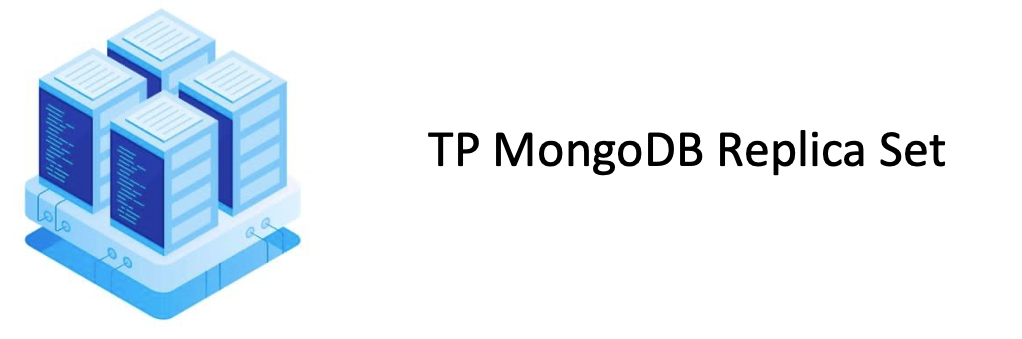



# Introduction

:::{important} Objectif

Dans ce TP, vous aborderez la réplication avec MongoDB avec une instance primaire et 2 instances secondaires. 
Vous apprendrez à utiliser la réplication en terme de :
* Haute disponibilité
* Répartition de charge
* Niveaux de cohérence


Lorsqu'une instance MongoDB est répliquée sur plusieurs instances, tel qu'illustré dans la figure ci-dessous, on parle de cluster en Replica Set.

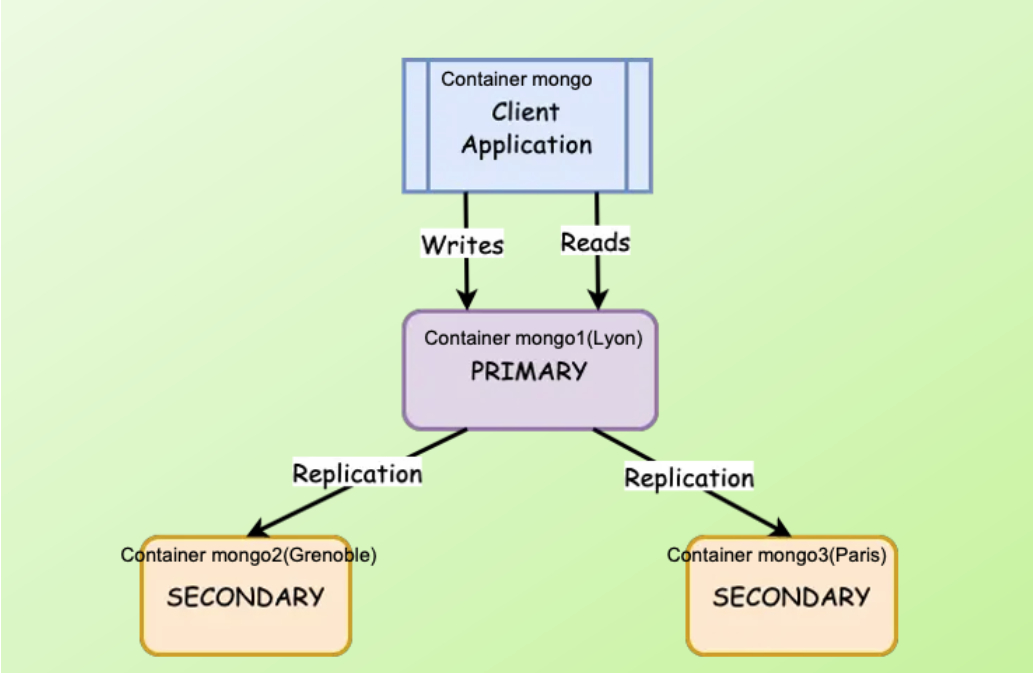

On supposera, dans le cadre de ce TP, que nous disposons de trois instances géographiquement distribuées :

- Une instance MongoDB à Paris
- Une instance MongoDB à Grenoble
- Une instance MongoDB à Lyon

Afin de se concentrer sur le sujet de la réplication, nous ne prendrons pas en compte les aspects liés à la sécurité, en particulier l'authentification."

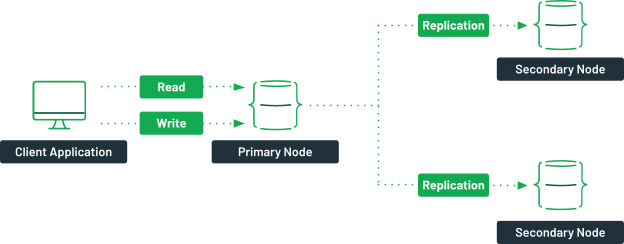

# Prérequis

* Ouvrez un terminal ssh sur la machine où docker a été installé, positionnez vous dans le répertoire docker.
* Ce terminal sera référencé comme #term1 et sera utilisé pour exécuter exclusivement les commandes Docker


# Déploiement d'une cluster MongoDB en mode réplica

Dans cette section, vous allez déployer trois conteneurs MongoDB (mongo1, mongo2, mongo3), chacun instanciant une instance de MongoDB. 
Vous configurerez ces instances pour permettre une communication entre elles, formant ainsi un cluster en mode réplica.

Ce cluster sera composé d'un nœud primaire et de deux nœuds secondaires, conformément à la description ci-dessous :

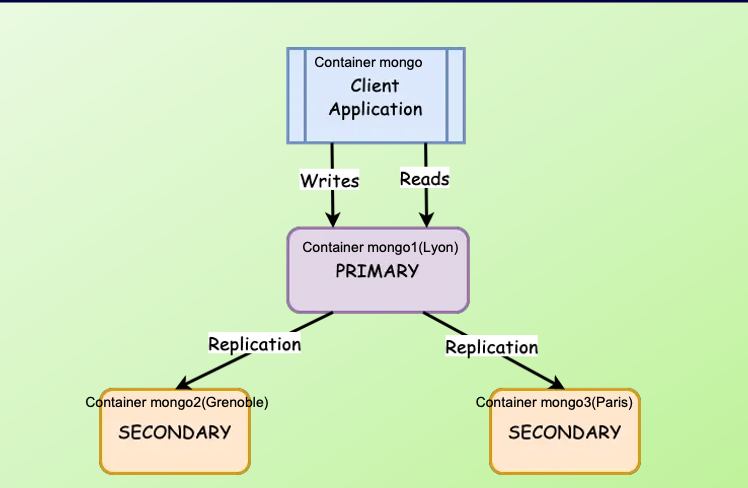

On utilisera le fichier de configuration `docker-compose.yml` pour construire notre cluster en utilisant les trois conteneurs mongo1, mongo2 et mongo3.

## 1 - Instancier les conteneurs mongo1, mongo2 et mongo3

Démarrer vos conteneurs mongo1, mongo2 et mongo3.

####  A partir de la documentation MongoDB ci-dessous, expliquer ce que réalise le service mongoinit de votre docker-compose.yml ?

:::{tip}Aide
La procédure pour implémenter un cluster en replica set est décrite ici :
[https://www.mongodb.com/docs/v4.4/tutorial/deploy-replica-set/#deploy-a-replica-set-in-the-terminal](https://www.mongodb.com/docs/v4.4/tutorial/deploy-replica-set/#deploy-a-replica-set-in-the-terminal)
:::


Exécuter le service mongoinit :



## 2 - Connexion au cluster MongoDB

Pour se connecter à notre cluster fraichement configuré, ouvrez un terminal qu'on appellera #term2.

A partir du terminal #term2 instancier notre conteneur `mongosingle` pour l'utiliser en tant que client pour accéder à notre cluster .

Votre container mongosingle dispose d'un client `mongo` pour nous connecter à distance à notre cluster Mongo.

#### A partir de la documentation ci-dessous établissez une connexion à votre cluster sur la base training ?

:::{note} Note
Utiliser la documentation [Connection-string ](https://www.mongodb.com/docs/manual/reference/connection-string/)
:::

Pour obtenir les informations sur les réplicas, Mongodb propose la commande `rs` pour détailler la configuration du cluster.
 
#### Avec la commande `rs.status()` vérifier le statut de la réplication et noter les noeuds primaires et secondaires ? 

# La réplication au service de la performance

## Introduction

Dans cette section, nous explorerons l'utilisation des instances MongoDB ayant le rôle "secondary" pour optimiser les performances.

Cette portion sera divisée en deux sections :
* Favoriser l'accès en lecture sur les instances "secondary"
* Définir une stratégie de répartition des lectures sur les instances "secondary"



## Privilégier les accès en lecture sur les "secondary"
Nous allons utiliser les instances secondaires pour améliorer les accès en lecture sur nos données :

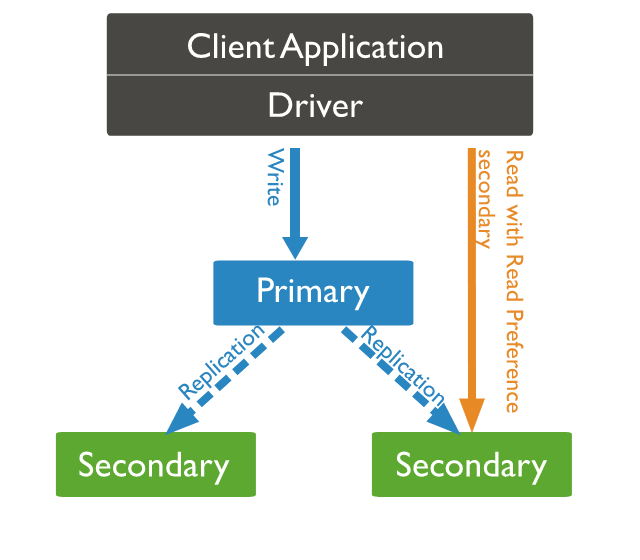


A partir de votre terminal #term1, charger des données dans la base training en utilisant le service docker mongodataimport:

Vérifions que nos données sont bien répliquées sur l'ensemble de nos instances mongo1, mongo2 et mongo3.

:::{note} Note
Pour permettre les lectures sur un mongo secondaire, il sera nécessaire d'autoriser les lectures avec la méthode db.getMongo().setSecondaryOk()

[https://www.mongodb.com/docs/v4.4/reference/method/Mongo.setSecondaryOk/](https://www.mongodb.com/docs/v4.4/reference/method/Mongo.setSecondaryOk/)
:::
    
Pour cela, ouvrer 3 terminaux term3, term4 et term5 et connectez vous directement à chaque instance mongodb

Alors disposez vous bien d'une collection movies dans la base training avec 88 documents ?

Super, on peut continuer !!!


On va en profiter pour la suite du TP pour activer le mode debug de chaque instance mongodb sur la base training  :

Nous allons également en profiter pour générer une seconde collection, "copymovies", que nous utiliserons ultérieurement.

Sur l'instance primaire, qui devrait logiquement être le #term 3, réalisez la copie de la collection "movies" vers une nouvelle collection nommée "copymovies".


On va à présent utiliser les terminaux term3, term4 et term5 pour tracer l'activité sur notre cluster. 

Vous disposez donc de 5 terminaux :

* term1: pour passer des commandes docker
* term2 : connexion au cluster
* term3, term4, term4 tracent respectivement l'activité sur les instances mongo1, mongo2 et mongo3. 

Commençons à jouer avec notre cluster !

Le choix de lire les données sur le primaire est la valeur par défaut prise par le client.

On peut modifier ce comportement en précisant dans note chaine de connexion nos préférences en lecture avec le paramètre read_preference ou en modifiant la valeur de notre session avec la méthode   setReadPref.

Essayons avec notre session en cours sur le terminal 2 :

Notre session va donc envoyer toutes les lectures sur les "secondary" et pour vérifier le comportement nous allons garder un oeil sur les logs Mongodb.

Sur votre terminal 2, connectez vous  la base training pour effectuer vos requêtes :

En consultant les logs des terminaux 3,4 et 5, vous remarquerez que l'un des terminaux affiche la trace de vos requêtes exécutées :


Si vous identifiez le container mongo qui a pris en charge la requête vous remarquerez qu'il s'agit d'un "secondary" .

C'est cool vous trouvez pas !!! 

La fonction de router est assurée par le client lui-même et c'est lui qui va rediriger les requêtes sur les instances secondaires de MongoDB.

Dans le cas d'une application, la version des drivers sera un élément critique pour veiller à la bonne répartition des requêtes.

En effet, le client fait parti du cluster et est abonné aux évènements qui se produit sur le cluster.

Pour utiliser le mode readpreference, on peut aussi le spécifier lors de la connexion comme on vient de le faire avec  `db.getMongo().setReadPref('secondary')` ou dans la chaine de connexion :


:::{warning} ATTENTION

Le client mongo shell dont la version est inférieur à 5 présente un bug empêchant l'interprétation correcte de l'option dans la chaîne de connexion (cf [https://jira.mongodb.org/browse/SERVER-39222](https://jira.mongodb.org/browse/SERVER-39222)).

En conséquence, dans cette situation, votre seul choix viable serait d'opter pour l'utilisation de la commande `db.getMongo().setReadPref({mode:'secondary'})`.

:::

Ainsi, il est possible de décharger les opérations de lecture du `primaire` vers les `secondaires`, préservant ainsi le `primaire` pour les opérations d'écriture.

Cette architecture permet une mise à l'échelle, ou extensibilité, en termes d'opérations de lecture. Toutefois, cette solution présente des limitations pour les opérations en écriture.

De plus, cette approche primaire/secondaire peut entraîner l'exécution d'opérations de lecture sur des secondaires éloignés du client, ce qui peut potentiellement augmenter les temps de réponse. 
Imaginons qu'un client situé à Grenoble accède à l'instance MongoDB à Paris, les délais de communication seront plus longs que s'il communiquait avec l'instance de Grenoble.

Pour remédier à cette problématique, MongoDB a mis en place une solution reposant sur l'utilisation de TAGs.

### Stratégie de répartition des lectures sur les "secondary"

Afin de faire face à la mondialisation croissante des applications, il est recommandé d'optimiser la proximité des données par rapport aux applications.

Il peut donc être astucieux de déployer des nœuds secondaires MongoDB dans des emplacements géographiques aussi proches que possible de vos applications. Dans de nombreux systèmes de gestion de base de données NoSQL, l'utilisation de tags permet de qualifier la situation géographique des instances secondaires, offrant ainsi aux clients la possibilité de sélectionner le nœud secondaire le plus proche d'eux.

Dans le contexte de notre cluster MongoDB, supposons que notre application soit répartie entre Lyon, Grenoble et Paris.

Étant donné que le site principal est basé à Lyon, nous avons mis en place un cluster avec le nœud primaire hébergé à Lyon et les nœuds secondaires à Grenoble et Paris.

Afin de spécifier la localisation géographique de chaque instance MongoDB, nous allons associer un tag "ville" à chaque membre dans la configuration du cluster.

Pour effectuer cette opération, vous devrez modifier la configuration du cluster MongoDB, en rétablissant ensuite le mode en tant que "primaire" pour que vos modifications prennent effet.


#### A partir de la documentation MongoDB ci-dessous associer un tag ville à chaque membre du cluster :

[https://www.mongodb.com/docs/v4.4/tutorial/configure-replica-set-tag-sets/](https://www.mongodb.com/docs/v4.4/tutorial/configure-replica-set-tag-sets/)

On supposera dans cet exercice que : 
* mongo1 est à Lyon
* mongo2 est à Grenoble
* mongo3 est à Paris

Les membres sont maintenant dotés de labels, et nous pouvons désormais utiliser ces TAGs pour orienter les lectures non seulement en fonction du rôle (secondary/primary), mais également en fonction du TAG.

#### Sur le terminal 2, veuillez ajuster les préférences de lecture afin de rediriger les requêtes vers le site de Paris ?

[https://www.mongodb.com/docs/v4.4/reference/method/Mongo.setReadPref/](https://www.mongodb.com/docs/v4.4/reference/method/Mongo.setReadPref/)

En utilisant notre fameuse db training, exécuter une requête MongoDB sur la collection training.movies et consulter les logs de l'instance mongo3 :


Avec cette approche, il devient relativement aisé de diriger/distribuer les requêtes en fonction du niveau de performance et de cohérence désiré.

Nous avons constaté qu'il est possible de spécifier des préférences de lecture en fonction du mode primaire/secondaire ou de l'étiquette d'un membre du cluster. Il est toutefois important de noter que les bibliothèques de programmation offrent des fonctionnalités plus avancées, permettant de définir des préférences spécifiques à la base de données ou à la collection interrogée.

L'exemple ci-dessous présente un simple programme Python qui établit des préférences sur les secondaires pour la base de données "training":

Le code suivant est directement exécutable à partir du notebook. Il vous suffit de cliquer sur `run`.

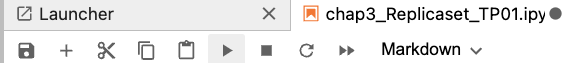

In [3]:
from pymongo import MongoClient
from pymongo.read_preferences import Secondary

# Création du connexion à MongoDB
client = MongoClient('mongodb://mongo1:27017,mongo2:27017,mongo3:27017/?replicaSet=my-mongo-set&ReadPreference=secondary')

# Connexion à la base training
training = client.training

# Par héritage notre objet training hérite des préférences de read établi à la connexion
training.read_preference

# Execution d'une requête sur la connexion movies
for doc in training.movies.find({'_id': 'movie:15'}):
    print(doc)
   
client.close()

{'_id': 'movie:15', 'title': 'Twelve Monkeys', 'year': 1995, 'genre': 'Science-fiction', 'summary': None, 'country': 'USA', 'director': {'_id': 'artist:33', 'last_name': 'Gilliam', 'first_name': 'Terry', 'birth_date': '1940'}, 'actors': [{'_id': 'artist:27', 'first_name': 'Bruce', 'last_name': 'Willis', 'birth_date': '1955', 'role': 'Cole'}]}


<font color='red'>A partir du programme ci-dessus modifier le code afin que la base training lise les données sur Grenoble :</font>

Indice : la documentation pymongo vous sera utile 
https://pymongo.readthedocs.io/en/stable/examples/high_availability.html?highlight=read_preference

In [4]:
from pymongo import MongoClient
from pymongo.read_preferences import Secondary
from time import sleep

#Compléter votre réponse

# Création du connexion à MongoDB
client = MongoClient('mongodb://mongo1:27017,mongo2:27017,mongo3:27017/?replicaSet=my-mongo-set')

# Connexion à la base training
training = client.get_database('training', read_preference=Secondary([{'ville': 'Grenoble'}]))

print(training.read_preference)

sleep(2)
# Execution d'une requête sur la connexion movies

# Execution d'une requête sur la connexion movies
for doc in training.movies.find({'_id': 'movie:15'}):
    print(doc)

print('Verifier les logs sur mongo2')

client.close()


Secondary(tag_sets=[{'ville': 'Grenoble'}], max_staleness=-1, hedge=None)
{'_id': 'movie:15', 'title': 'Twelve Monkeys', 'year': 1995, 'genre': 'Science-fiction', 'summary': None, 'country': 'USA', 'director': {'_id': 'artist:33', 'last_name': 'Gilliam', 'first_name': 'Terry', 'birth_date': '1940'}, 'actors': [{'_id': 'artist:27', 'first_name': 'Bruce', 'last_name': 'Willis', 'birth_date': '1955', 'role': 'Cole'}]}
Verifier les logs sur mongo2


#### Modifier le code python afin que les préférences de read respectent les contraintes suivantes ?
* les accès en lecture sur la collection movies sont réalisés sur le primaire
* les accès en lecture sur la collection copymovies sont réalisés sur l'instance Grenoble


:::{tip} Indice : 
la documentation pymongo vous sera utile 
[https://pymongo.readthedocs.io/en/stable/examples/high_availability.html?highlight=read_preference](https://pymongo.readthedocs.io/en/stable/examples/high_availability.html?highlight=read_preference)
::: 

In [5]:
from pymongo.read_preferences import Secondary
from pymongo import ReadPreference


#Compléter votre réponse

# Création du connexion à MongoDB
client = MongoClient('mongodb://mongo1:27017,mongo2:27017,mongo3:27017/?replicaSet=my-mongo-set&ReadPreference=secondary')

# Connexion à la base training
training = client.get_database('training', read_preference=Secondary([{'ville': 'Grenoble'}]))

# Connexion à la base training

movies = training.get_collection('movies', read_preference=ReadPreference.PRIMARY)

print("Preference read pour movies" , movies.read_preference)

copymovies = training.get_collection('copymovies', read_preference=Secondary([{'ville': 'Grenoble'}]))

print("Preference read pour copymovies" , copymovies.read_preference)

# Execution d'une requête sur la connexion movies
for doc in movies.find({'_id': 'movie:15'}):
    print(doc)

for doc in copymovies.find({'_id': 'movie:15'}):
    print(doc)

print('Verifier les logs sur mongo1')
print('Verifier les logs sur mongo2')
client.close()

Preference read pour movies Primary()
Preference read pour copymovies Secondary(tag_sets=[{'ville': 'Grenoble'}], max_staleness=-1, hedge=None)
{'_id': 'movie:15', 'title': 'Twelve Monkeys', 'year': 1995, 'genre': 'Science-fiction', 'summary': None, 'country': 'USA', 'director': {'_id': 'artist:33', 'last_name': 'Gilliam', 'first_name': 'Terry', 'birth_date': '1940'}, 'actors': [{'_id': 'artist:27', 'first_name': 'Bruce', 'last_name': 'Willis', 'birth_date': '1955', 'role': 'Cole'}]}
{'_id': 'movie:15', 'title': 'Twelve Monkeys', 'year': 1995, 'genre': 'Science-fiction', 'summary': None, 'country': 'USA', 'director': {'_id': 'artist:33', 'last_name': 'Gilliam', 'first_name': 'Terry', 'birth_date': '1940'}, 'actors': [{'_id': 'artist:27', 'first_name': 'Bruce', 'last_name': 'Willis', 'birth_date': '1955', 'role': 'Cole'}]}
Verifier les logs sur mongo1
Verifier les logs sur mongo2


Le client MongoDB nous donne assez de flexibilité pour définir nos préférences afin d'améliorer les performances mais qu'en est il du niveau du cohérence ?

C'est ce que nous allons voir dans la section suivante.

## La cohérence

Pour rappel, le thèoreme de CAP est l'acronyme de :
* Consistency (cohérence): La cohérence signifie que tous les clients voient les mêmes données en même temps, quel que soit le nœud auquel ils se connectent.
* Availability (disponibilité): La disponibilité signifie qu'un client qui effectue une requête de données obtient une réponse, même si un ou plusieurs nœuds sont en panne.
* Partition Tolerance (distribution): La tolérance au partitionnement signifie que la grappe (cluster) doit continuer à fonctionner quel que soit le nombre d'interruptions entre les nœuds du système.

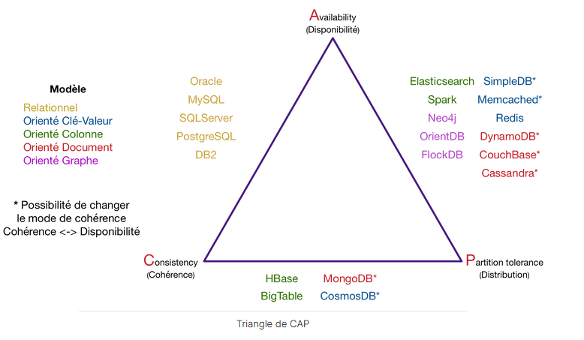

Dans la figure ci-dessus MongoDB est classé CP sur le théorème et nous allons voir que ce n'est pas tout à fait vrai.

### Write concern

La cohérence à l'écriture dans le contexte des Systèmes de Gestion de Base de Données (SGBD) NoSQL fait référence à la garantie que toutes les copies des données dans un système distribué seront mises à jour de manière synchronisée et cohérente lorsqu'une opération d'écriture est effectuée.

Cela garantit une cohérence stricte entre les différentes instances de la base de données, car l'insertion n'est confirmée qu'après avoir été répliquée sur l'ensemble des instances du cluster (mongo1, mongo2, mongo3). Cependant, cette approche peut entraîner une perte de performance en écriture, car elle introduit un délai d'attente lié à la réplication sur tous les nœuds.

Dans certains cas, pour améliorer les performances au détriment d'une cohérence immédiate, il est possible de configurer le système pour qu'il n'attende pas la validation sur l'ensemble des instances, mais seulement sur le nœud primaire. Cela peut être réalisé en ajustant les paramètres de cohérence à l'écriture pour autoriser des niveaux de réplication asynchrones sur les nœuds secondaires, permettant ainsi à l'opération d'écriture d'être confirmée plus rapidement. Cependant, cela peut entraîner une légère désynchronisation entre les nœuds secondaires et le nœud primaire. Le choix entre cohérence immédiate et performances optimisées dépend des besoins spécifiques de l'application et des compromis acceptables en termes de cohérence des données.


Dans l'exemple ci-dessous, le client attend la validation en écriture sur le primaire et un secondaire ce qui expose à d'eventuelles incohérences en lecture dans le cas où la lecture est réalisé sur le 3eme noeud.


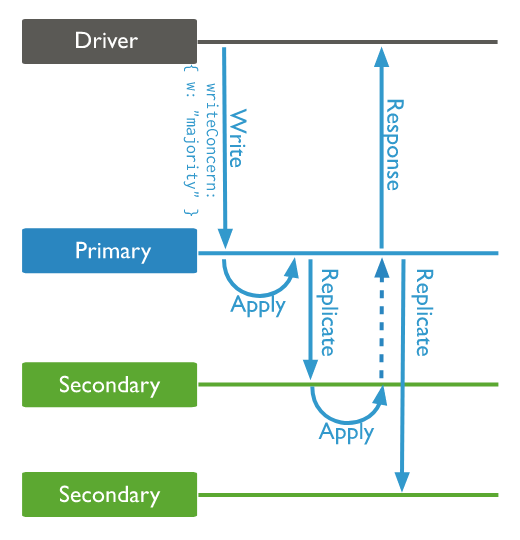



Vérifions cela en pratique mais avant tout regardons la configuration par défaut du niveau de cohérence  :

:::{note} Note

Les liens suivants pourront vous aider pour comprendre le comportement par défaut :

[https://www.mongodb.com/docs/v4.4/reference/mongodb-defaults/#write-concern](https://www.mongodb.com/docs/v4.4/reference/mongodb-defaults/#write-concern)

Pour vérifier la configuration, utiliser la documentation suivante :

[https://www.mongodb.com/docs/v4.4/reference/command/getDefaultRWConcern/#replica-sets](https://www.mongodb.com/docs/v4.4/reference/command/getDefaultRWConcern/#replica-sets)

:::


#### Interpréter la configuration par défaut pour les écritures : ?

Pour personnaliser le comportement par défaut, il est possible de spécifier, lors de la modification, le niveau d'écriture souhaité.

On est d'accord on voit pas ce que cela change. 

Pour mieux comprendre la différence arrêter mongo2 à partir du terminal 1

On voit sur les terminaux 4 et 5, ils déplorent la disparition de mongo1.

Vérifions sur le terminal 2 la configuration de notre cluster, ne vous inquiétez pas cela ne perturbera notre terminal 2

Essayer de réinsérer votre document :

#### Expliquer le comportement de MongoDB et faites la relation avec le theoreme de CAP ?


#### Annuler l'insertion précédente et corriger l'insertion afin que celle-ci s'exécute malgré la panne de mongo1  ?

Bien entendu, si vous redémarrez mongo2 celui-ci va réintégrer le cluster et rattraper son retard grâce aux journaux d'opération `op-log`.

Pendant la phase de récupération de mongo2, les lectures sur celui-ci peuvent être incohérentes en raison de la nécessité de resynchroniser les données après une panne. Pour minimiser les incohérences en lecture, quelle recommendation préconniser-vous?




# Conclusion 

Dans les systèmes distribués, la cohérence est un compromis entre les accès en lecture et en écriture, et elle peut être ajustée en fonction des besoins spécifiques de l'application. Cependant, il est important de noter que ce réglage de la cohérence se fait généralement au détriment de la disponibilité, comme le souligne le théorème CAP.

Le concept BASE, qui signifie Basically Available, Soft state, Eventually consistent, met en avant cette approche en reconnaissant que dans certains cas, il peut être acceptable d'avoir un état système qui n'est pas toujours strictement cohérent à tout moment (Soft state). Cette approche permet une disponibilité élevée (Basically Available) et peut atteindre la cohérence au fil du temps (Eventually consistent).

Ainsi, l'application a la flexibilité de choisir le niveau de cohérence nécessaire en fonction de ses exigences particulières, tout en étant consciente des compromis qui peuvent découler de ces choix, notamment en termes de disponibilité. Cela reflète une approche pragmatique dans la conception de systèmes distribués, où les besoins spécifiques de l'application guident les décisions relatives à la cohérence et à la disponibilité.